# Multinomial Distribution

`Multinomial(n, p)` generalizes the binomial distribution to more than two outcomes. It models the counts of each category across `n` independent trials, where each trial lands in one of several categories with the fixed probabilities `p`.

In [21]:
from symbulate import *

## Draw a value

Each draw is a vector of counts, one per category, summing to `n`.

In [22]:
Multinomial(n=10, p=[0.5, 0.3, 0.2]).draw()

(4, 5, 1)

## Simulate

Every simulated value is a vector of counts summing to `n`.

In [23]:
Multinomial(n=10, p=[0.5, 0.3, 0.2]).sim(1000)

0,"(4, 4, 2)"
1,"(4, 3, 3)"
2,"(6, 4, 0)"
3,"(5, 4, 1)"
4,"(7, 1, 2)"
5,"(4, 4, 2)"
6,"(6, 2, 2)"
7,"(5, 5, 0)"
8,"(3, 4, 3)"
...,...
999,"(4, 4, 2)"


## Mean, variance, and standard deviation

For a vector-valued distribution these return one value per category.

In [24]:
X = Multinomial(n=10, p=[0.5, 0.3, 0.2])
X.mean(), X.var(), X.sd()

((5.0, 3.0, 2.0),
 (2.5, 2.1, 1.5999999999999999),
 (1.5811388300841898, 1.449137674618944, 1.2649110640673518))

## Covariance matrix

`cov()` returns the full covariance matrix. Its diagonal holds the per-category variances. 

In [25]:
X.cov()

array([[ 2.5, -1.5, -1. ],
       [-1.5,  2.1, -0.6],
       [-1. , -0.6,  1.6]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1.

In [26]:
X.corr()

array([[ 1.        , -0.65465367, -0.5       ],
       [-0.65465367,  1.        , -0.32732684],
       [-0.5       , -0.32732684,  1.        ]])

## Evaluate the probability of an outcome

The probability of a specific set of counts (which must sum to `n`).

In [27]:
Multinomial(n=10, p=[0.5, 0.3, 0.2]).pdf([5, 3, 2])

np.float64(0.08504999999999999)

## Relationship: each count is marginally Binomial

Looking at a single category and lumping all the others together is just a two-outcome (success/failure) experiment, so each count `X_i` is marginally `Binomial(n, p_i)`. Here the first count of `Multinomial(20, [0.5, 0.3, 0.2])` is `Binomial(20, 0.5)`.

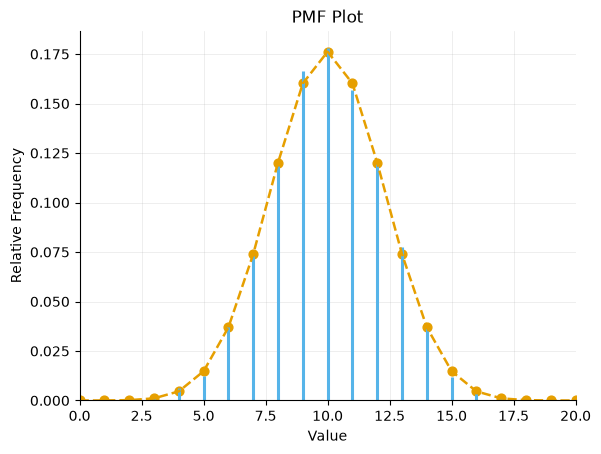

In [28]:
A, B, C = RV(Multinomial(n=20, p=[0.5, 0.3, 0.2]))
A.sim(10000).plot()
Binomial(n=20, p=0.5).plot()

## Relationship: two categories is a Binomial

With only two categories the multinomial is exactly a binomial: the first count of `Multinomial(n, [p, 1 - p])` is `Binomial(n, p)`.

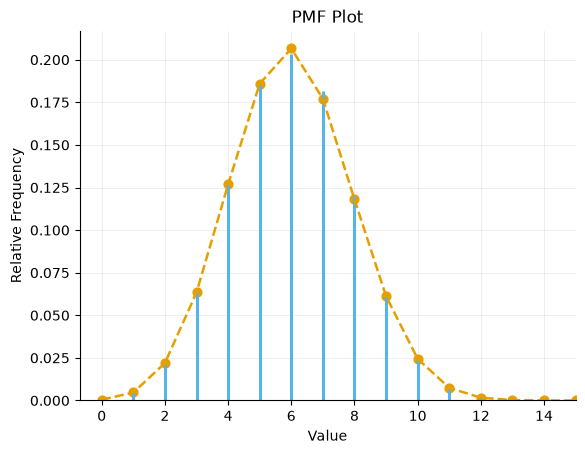

In [29]:
D, E = RV(Multinomial(n=15, p=[0.4, 0.6]))
D.sim(10000).plot()
Binomial(n=15, p=0.4).plot()